# Word-Level Dialect Analysis
Cross-compares every source word against every word in the DAT and DIT transcripts using:

- **Levenshtein similarity**
- **Position score** (normalised gap between source and target word index)

Scoring methods:
- **Combined Weighted Score**: $\alpha \cdot \text{lev\_sim} + (1-\alpha) \cdot \text{pos\_sim}$, evaluated for $\alpha \in \{0.25,\ 0.5,\ 0.75\}$
- **Combined Harmonic Score**: $\frac{2 \cdot \text{lev\_sim} \cdot \text{pos\_sim}}{\text{lev\_sim} + \text{pos\_sim}}$

## Preparation

In [170]:
import sys
import importlib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# Make scripts/ importable when running from inside scripts/
sys.path.insert(0, str(Path("__file__").resolve().parent))

import util.utils as utils
importlib.reload(utils)

from util.utils import (
    clean,
    generate_cross_comparison_df,
)

In [171]:
PROJECT_ROOT = Path("__file__").resolve().parent.parent
ANALYSIS_DIR = PROJECT_ROOT / "samples"
DAT_TSV = ANALYSIS_DIR / "dialect-aware-transcript.tsv"
DIT_TSV = ANALYSIS_DIR / "dialect-ignorant-transcript.tsv"

## Load & merge data

In [172]:
df_dit = pd.read_csv(DIT_TSV, sep='\t', encoding='utf-8-sig')
df_dat = pd.read_csv(DAT_TSV, sep='\t', encoding='utf-8-sig')
df = pd.merge(df_dit, df_dat[['path', 'DAT']], on='path', how='inner')

print(f"Clips: {len(df)}")
df.head()

Clips: 100


,path,duration,sentence,sentence_source,client_id,dialect_region,canton,zipcode,age,gender,DIT,DAT
0,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,4.778662,Insgesamt habe ich einige Hunderttausend Frank...,news,300bb931-79ae-40ec-b989-3efd5e83f4c2,Zürich,ZH,8408.0,fourties,male,Insgesamt habe ich einige hundert Dusik vor un...,Insgesamt habe ich einige 100.000 Franken verl...
1,clips\6e084270-8d26-43d9-ba69-5e8ee793ab8c\dca...,5.294150,Welche Rolle hatte Rosenberg während des Holoc...,news,6e084270-8d26-43d9-ba69-5e8ee793ab8c,Zürich,ZG,6340.0,twenties,female,"Weli Rolle, höchter Uz stoodhergewerden von Ho...",Wer ironne hättet viele bands auf den einzugem...
2,clips\6858a37b-edd0-4fdf-871c-96d3b1bd3e21\82f...,5.802676,Das ist angesichts aller schlechten Optionen d...,news,6858a37b-edd0-4fdf-871c-96d3b1bd3e21,Zürich,ZH,8704.0,fourties,male,Das ist angesichts vor allen Schlachten Option...,Das ist angesichts von allen schlechten Option...
3,clips\c4c03e6f-50a2-4d24-ae88-caf3032798fa\a21...,5.973333,Ebenfalls keinen Sieg durfte die AC Milan feiern.,news,c4c03e6f-50a2-4d24-ae88-caf3032798fa,Zürich,AG,4663.0,fourties,male,Aber voll ScreenZig hat 100 000 derumphierig,Aber falls kein Sieg hat AC Milan Dörfe 4.
4,clips\f877ee50-af2b-423b-bdda-0cc406032c45\4e5...,4.778662,Viele Fussballfans haben die Alte Reithalle un...,parliament,f877ee50-af2b-423b-bdda-0cc406032c45,Zürich,ZH,8405.0,fourties,female,Viele Fußballfans hängt die Alldri-Taller unte...,Viele Fußballfans handt die All 3 Taller unter...


In [173]:
df[["sentence", "DIT", "DAT"]].isna().sum()

sentence    0
DIT         0
DAT         0
dtype: int64

## Determine global normalisation constants

In [174]:
all_words = (
    df['sentence'].dropna().str.split().explode().tolist()
    + df['DIT'].dropna().str.split().explode().tolist()
    + df['DAT'].dropna().str.split().explode().tolist()
)
all_sentences = pd.concat([df['sentence'].dropna(), df['DIT'].dropna(), df['DAT'].dropna()])

global_max_word_length     = max(len(clean(w)) for w in all_words)
global_max_sentence_length = max(len(str(s).split()) for s in all_sentences)

print(f"Global max word length     (Levenshtein normaliser): {global_max_word_length}")
print(f"Global max sentence length (position normaliser):    {global_max_sentence_length}")

Global max word length     (Levenshtein normaliser): 27
Global max sentence length (position normaliser):    65


## Helper Functions

In [175]:
def _hist_ax(ax, data, title):
    """Draw a single histogram panel."""
    ax.hist(data.dropna(), bins=50, color="#4C72B0", edgecolor="white", linewidth=0.4)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Score (0 – 1)", fontsize=9)
    ax.set_ylabel("Count", fontsize=9)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(0.2))
    ax.set_xlim(0, 1)
    mean_val = data.dropna().mean()
    ax.axvline(mean_val, color="#DD5544", linewidth=1.2, linestyle="--",
               label=f"Mean: {mean_val:.3f}")
    ax.legend(fontsize=8)


def plot_base_scores(word_comparison_results):
    """Alpha-independent scores: DIT Word Score, DAT Word Score, Position Score, DIT Harmonic, DAT Harmonic."""
    cols = [
        ("DIT Word Score", "dit_word_score"),
        ("DAT Word Score", "dat_word_score"),
        ("Position Score", "position_score"),
        ("DIT Combined Harmonic", "dit_score_harmonic"),
        ("DAT Combined Harmonic", "dat_score_harmonic"),
    ]
    fig, axes = plt.subplots(1, 5, figsize=(26, 4))
    for ax, (title, col) in zip(axes, cols):
        _hist_ax(ax, word_comparison_results[col], title)
    plt.suptitle("Base Score Distributions (alpha-independent)", fontsize=13)
    plt.tight_layout()
    plt.show()


def plot_combined_scores(word_comparison_results_by_alpha, alphas):
    """Combined weighted scores compared side-by-side across alphas.
    Rows: DIT Weighted, DAT Weighted.
    Columns: one per alpha value.
    """
    transcript_types = [
        ("DIT Combined Weighted", "dit_score_weighted"),
        ("DAT Combined Weighted", "dat_score_weighted"),
    ]
    n_rows = len(transcript_types)
    n_cols = len(alphas)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows),
                             sharey='row')
    for row_idx, (base_title, col) in enumerate(transcript_types):
        for col_idx, alpha in enumerate(alphas):
            ax = axes[row_idx][col_idx]
            _hist_ax(ax, word_comparison_results_by_alpha[alpha][col], f"{base_title} alpha = {alpha}")
    plt.suptitle("Combined Weighted Score Distributions — alpha comparison", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


def best_matchings_df(word_comparison_results_df, transcript, score_type="weighted"):
    """Return the best matching target word per source word position.

    Parameters
    ----------
    word_comparison_results_df : DataFrame from generate_cross_comparison_df
    transcript                 : "DIT" or "DAT"
    score_type                 : "weighted" or "harmonic"
    """
    score_col = f"{transcript.lower()}_score_{score_type}"
    word_col  = f"{transcript.lower()}_word"
    return word_comparison_results_df.loc[
        word_comparison_results_df.groupby(['clip_id', 'src_word_index'], sort=False)[score_col].idxmax()
    ][['clip_id', 'src_word_index', 'src_word', word_col, score_col]].reset_index(drop=True)


## Analysis

### Build word-level DataFrames

In [176]:
ALPHAS = [0.25, 0.5, 0.75]

word_comparison_results_by_alpha = {
    alpha: generate_cross_comparison_df(df, global_max_word_length, global_max_sentence_length, alpha=alpha)
    for alpha in ALPHAS
}

print(f"Total rows per DataFrame: {len(next(iter(word_comparison_results_by_alpha.values()))):,}")

Total rows per DataFrame: 9,441


### Comparative summary statistics

Alpha-independent scores (`dit_word_score`, `dat_word_score`, `position_score`, harmonic scores) are identical across all runs and shown once.
The weighted scores change with α and are compared side-by-side.

In [177]:
# Alpha-independent scores
word_comparison_results_by_alpha[0.5][[
    'dit_word_score', 'dat_word_score', 'position_score',
    'dit_score_harmonic', 'dat_score_harmonic',
]].describe().round(3)

,dit_word_score,dat_word_score,position_score,dit_score_harmonic,dat_score_harmonic
count,9441.000,9441.000,9441.000,9441.000,9441.000
mean,0.701,0.627,0.897,0.734,0.681
std,0.264,0.333,0.156,0.280,0.351
min,0.000,0.000,0.000,0.000,0.000
25%,0.667,0.593,0.906,0.738,0.716
50%,0.778,0.778,0.953,0.844,0.844
75%,0.852,0.852,0.969,0.893,0.893
max,1.000,1.000,1.000,1.000,1.000


In [178]:
# Weighted scores - compared across all three alpha values
pd.concat(
    {f"α={a}": word_comparison_results_by_alpha[a][['dit_score_weighted', 'dat_score_weighted']].describe().round(3)
     for a in ALPHAS},
    axis=1
)

α=0.25                                 α=0.5  \
      dit_score_weighted dat_score_weighted dit_score_weighted   
count           9441.000           9441.000           9441.000   
mean               0.775              0.723              0.751   
std                0.291              0.367              0.274   
min                0.000              0.000              0.000   
25%                0.823              0.828              0.765   
50%                0.895              0.895              0.853   
75%                0.930              0.930              0.899   
max                1.000              1.000              1.000   

                                     α=0.75                     
      dat_score_weighted dit_score_weighted dat_score_weighted  
count           9441.000           9441.000           9441.000  
mean               0.691              0.726              0.659  
std                0.353              0.265              0.342  
min                0.000              0.000              0.000  
25%                0.758              0.719              0.672  
50%                0.853              0.818              0.810  
75%                0.899              0.873              0.877  
max                1.000              1.000              1.000

### Full Word-to-Word Cross-Comparison — Single Clip (index 2)

Exhaustive mapping of every source word against every word in the DIT and DAT transcripts for a single example clip.

In [179]:
# Select the clip at DataFrame index 2
example_clip_id = df.iloc[2]["path"]

print(f"Clip ID : {example_clip_id}")
print(f"Source  : {df.iloc[2]['sentence']}")
print(f"DIT     : {df.iloc[2]['DIT']}")
print(f"DAT     : {df.iloc[2]['DAT']}")

base_cols = [
    "src_word_index", "target_word_index",
    "src_word", "dit_word", "dat_word",
    "dit_word_score", "dat_word_score", "position_score",
    "dit_score_harmonic", "dat_score_harmonic",
]
example_clip_cross_comparison_df = (
    word_comparison_results_by_alpha[ALPHAS[0]]
    .loc[word_comparison_results_by_alpha[ALPHAS[0]]["clip_id"] == example_clip_id, base_cols]
    .reset_index(drop=True)
)

for alpha in ALPHAS:
    alpha_df = (
        word_comparison_results_by_alpha[alpha]
        .loc[word_comparison_results_by_alpha[alpha]["clip_id"] == example_clip_id,
             ["src_word_index", "target_word_index", "dit_score_weighted", "dat_score_weighted"]]
        .rename(columns={
            "dit_score_weighted": f"dit_score_weighted_α{alpha}",
            "dat_score_weighted": f"dat_score_weighted_α{alpha}",
        })
    )
    example_clip_cross_comparison_df = example_clip_cross_comparison_df.merge(
        alpha_df, on=["src_word_index", "target_word_index"]
    )


Clip ID : clips\6858a37b-edd0-4fdf-871c-96d3b1bd3e21\82f96cf51a7b4d1239325b81c305870fd7e997b57e21c307560debad119e0417.flac
Source  : Das ist angesichts aller schlechten Optionen die beste.
DIT     : Das ist angesichts vor allen Schlachten Optionen, die beste.
DAT     : Das ist angesichts von allen schlechten Optionen die Best.


In [180]:

dit_all_pairs_cols = (
    ["src_word_index", "target_word_index", "src_word", "dit_word",
     "dit_word_score", "position_score", "dit_score_harmonic"]
    + [f"dit_score_weighted_α{a}" for a in ALPHAS]
)
df_cross_compare_dit = example_clip_cross_comparison_df[dit_all_pairs_cols].sort_values(
    ["src_word_index", "target_word_index"]
).reset_index(drop=True)
df_cross_compare_dit.head()


,src_word_index,target_word_index,src_word,dit_word,dit_word_score,position_score,dit_score_harmonic,dit_score_weighted_α0.25,dit_score_weighted_α0.5,dit_score_weighted_α0.75
0,0,0,das,das,1.000,1.000,1.000,1.000,1.000,1.000
1,0,1,das,ist,0.889,0.984,0.934,0.960,0.936,0.913
2,0,2,das,angesichts,0.667,0.969,0.790,0.893,0.818,0.743
3,0,3,das,vor,0.889,0.953,0.920,0.937,0.921,0.905
4,0,4,das,allen,0.815,0.938,0.872,0.907,0.876,0.846


In [181]:
# DAT: all (source word, DAT word) pairs for the example clip
dat_all_pairs_cols = (
    ["src_word_index", "target_word_index", "src_word", "dat_word",
     "dat_word_score", "position_score", "dat_score_harmonic"]
    + [f"dat_score_weighted_α{a}" for a in ALPHAS]
)
example_clip_cross_comparison_df[dat_all_pairs_cols].sort_values(
    ["src_word_index", "target_word_index"]
).reset_index(drop=True)


,src_word_index,target_word_index,src_word,dat_word,dat_word_score,position_score,dat_score_harmonic,dat_score_weighted_α0.25,dat_score_weighted_α0.5,dat_score_weighted_α0.75
0,0,0,das,das,1.000,1.000,1.000,1.000,1.000,1.000
1,0,1,das,ist,0.889,0.984,0.934,0.960,0.936,0.913
2,0,2,das,angesichts,0.667,0.969,0.790,0.893,0.818,0.743
3,0,3,das,von,0.889,0.953,0.920,0.937,0.921,0.905
4,0,4,das,allen,0.815,0.938,0.872,0.907,0.876,0.846
...,...,...,...,...,...,...,...,...,...,...
67,7,4,beste,allen,0.815,0.953,0.879,0.918,0.884,0.849
68,7,5,beste,schlechten,0.741,0.969,0.840,0.912,0.855,0.798
69,7,6,beste,optionen,0.741,0.984,0.845,0.923,0.863,0.802
70,7,7,beste,die,0.852,1.000,0.920,0.963,0.926,0.889


### Score distributions

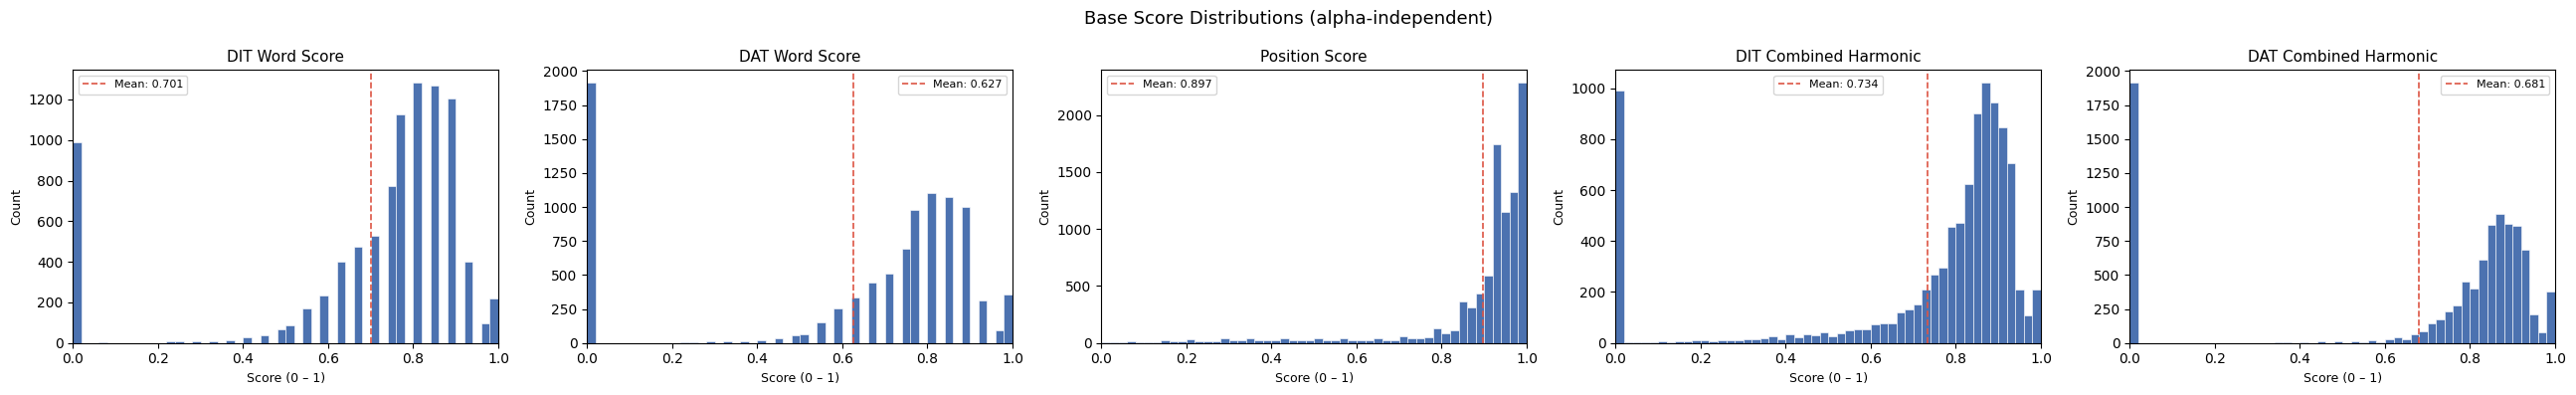

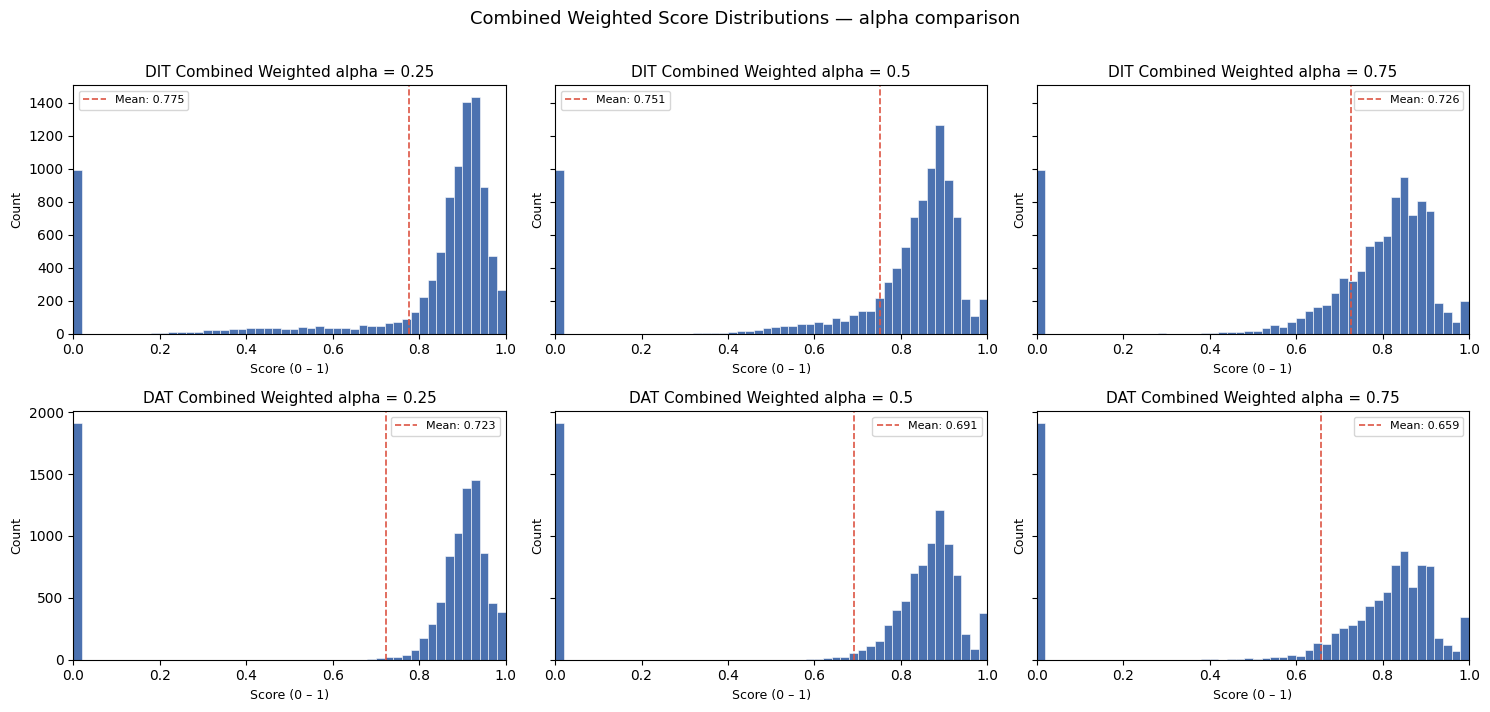

In [182]:
# 1) Base scores (alpha-independent) — shown once
plot_base_scores(next(iter(word_comparison_results_by_alpha.values())))

# 2) Combined scores for all alphas side-by-side
plot_combined_scores(word_comparison_results_by_alpha, ALPHAS)

### Best matchings: Harmonic (alpha-independent)

In [183]:
df_dit_harmonic = best_matchings_df(word_comparison_results_by_alpha[0.5], "DIT", score_type="harmonic")
df_dit_harmonic.head()

,clip_id,src_word_index,src_word,dit_word,dit_score_harmonic
0,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,0,insgesamt,insgesamt,1.000
1,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,1,habe,habe,1.000
2,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,2,ich,ich,1.000
3,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,3,einige,einige,1.000
4,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,4,hunderttausend,hundert,0.851


In [184]:
df_dat_harmonic = best_matchings_df(word_comparison_results_by_alpha[0.5], "DAT", score_type="harmonic")
df_dat_harmonic.head()


,clip_id,src_word_index,src_word,dat_word,dat_score_harmonic
0,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,0,insgesamt,insgesamt,1.000
1,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,1,habe,habe,1.000
2,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,2,ich,ich,1.000
3,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,3,einige,einige,1.000
4,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,4,hunderttausend,franken,0.768


### Best matchings: Weighted α = 0.25

In [185]:
df_dit_high_pos = best_matchings_df(word_comparison_results_by_alpha[0.25], "DIT", score_type="weighted")
df_dit_high_pos.head()

,clip_id,src_word_index,src_word,dit_word,dit_score_weighted
0,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,0,insgesamt,insgesamt,1.000
1,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,1,habe,habe,1.000
2,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,2,ich,ich,1.000
3,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,3,einige,einige,1.000
4,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,4,hunderttausend,hundert,0.935


In [186]:
df_dat_high_pos = best_matchings_df(word_comparison_results_by_alpha[0.25], "DAT", score_type="weighted")
df_dat_high_pos.head()

,clip_id,src_word_index,src_word,dat_word,dat_score_weighted
0,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,0,insgesamt,insgesamt,1.000
1,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,1,habe,habe,1.000
2,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,2,ich,ich,1.000
3,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,3,einige,einige,1.000
4,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,4,hunderttausend,franken,0.895


### Best matchings: Weighted α = 0.5

In [187]:
df_dit_eq = best_matchings_df(word_comparison_results_by_alpha[0.5], "DIT", score_type="weighted").head(100)
df_dit_eq.head()

,clip_id,src_word_index,src_word,dit_word,dit_score_weighted
0,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,0,insgesamt,insgesamt,1.000
1,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,1,habe,habe,1.000
2,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,2,ich,ich,1.000
3,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,3,einige,einige,1.000
4,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,4,hunderttausend,hundert,0.871


In [188]:
df_dat_eq = best_matchings_df(word_comparison_results_by_alpha[0.5], "DAT", score_type="weighted")
df_dat_eq.head()


,clip_id,src_word_index,src_word,dat_word,dat_score_weighted
0,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,0,insgesamt,insgesamt,1.000
1,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,1,habe,habe,1.000
2,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,2,ich,ich,1.000
3,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,3,einige,einige,1.000
4,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,4,hunderttausend,franken,0.807


### Best matchings: Weighted α = 0.75

In [189]:
df_dit_high_lev = best_matchings_df(word_comparison_results_by_alpha[0.75], "DIT", score_type="weighted")
df_dit_high_lev.head()


,clip_id,src_word_index,src_word,dit_word,dit_score_weighted
0,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,0,insgesamt,insgesamt,1.000
1,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,1,habe,habe,1.000
2,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,2,ich,ich,1.000
3,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,3,einige,einige,1.000
4,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,4,hunderttausend,hundert,0.806


In [190]:
df_dat_high_lev = best_matchings_df(word_comparison_results_by_alpha[0.75], "DAT", score_type="weighted")
df_dat_high_lev.head()


,clip_id,src_word_index,src_word,dat_word,dat_score_weighted
0,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,0,insgesamt,insgesamt,1.000
1,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,1,habe,habe,1.000
2,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,2,ich,ich,1.000
3,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,3,einige,einige,1.000
4,clips\300bb931-79ae-40ec-b989-3efd5e83f4c2\83c...,4,hunderttausend,franken,0.719
